# Reconocimiento de placas en via de lastre

Ejecuta las celdas **en orden**. Hay una sola pausa obligatoria, en la celda 3,
que pide reiniciar el entorno.

**Antes de empezar:** activa la GPU en `Entorno de ejecucion > Cambiar tipo de
entorno de ejecucion > GPU`. Cambiarla despues reinicia todo.

## 1. Ver que GPU y que CUDA hay

In [ ]:
!nvidia-smi --query-gpu=name,driver_version --format=csv,noheader
!nvcc --version | grep release
import sys; print("Python", sys.version.split()[0])

Tesla T4, 580.82.07
Cuda compilation tools, release 12.8, V12.8.93
Python 3.13.15


## 2. Montar tu Google Drive

Aprueba la ventana emergente.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 3. Instalar dependencias

`onnxruntime-gpu` se fija a la version 1.22.0 a proposito. Las versiones mas
nuevas estan compiladas contra CUDA 13, y Colab trae CUDA 12: cargan mal y el
proceso cae a procesador sin avisar.

La instalacion **no** va en modo silencioso, para que puedas ver que version
quedo si algo falla.

**Al terminar, reinicia el entorno** (`Entorno de ejecucion > Reiniciar entorno
de ejecucion`) y sigue en la celda 4.

In [ ]:
!pip install -q opencv-python-headless numpy openpyxl pillow
!pip install -q fast-alpr open-image-models

# La version importa: 1.23 en adelante exige CUDA 13, que Colab no tiene.
!pip uninstall -y onnxruntime onnxruntime-gpu
!pip install "onnxruntime-gpu==1.22.0"

print()
print("=" * 62)
print("REINICIA EL ENTORNO DE EJECUCION Y SIGUE EN LA CELDA 4")
print("=" * 62)

Found existing installation: onnxruntime-gpu 1.22.0
Uninstalling onnxruntime-gpu-1.22.0:
  Successfully uninstalled onnxruntime-gpu-1.22.0
  Using cached onnxruntime_gpu-1.22.0-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.1 kB)
Using cached onnxruntime_gpu-1.22.0-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (283.2 MB)

REINICIA EL ENTORNO DE EJECUCION Y SIGUE EN LA CELDA 4


## 4. Traer el codigo

Se puede ejecutar las veces que quieras.

In [ ]:
import os

if os.path.isdir('/content/lastre/.git'):
    %cd /content/lastre
    !git pull --quiet
else:
    !rm -rf /content/lastre
    !git clone --quiet https://github.com/riofutabac/PLACAS-RECONOCIMIENTO.git /content/lastre
    %cd /content/lastre

!git log --oneline -1

/content/lastre
3ad0c40 (HEAD -> main, origin/main, origin/HEAD) fix: celdas del cuaderno independientes del directorio de trabajo


## 5. Comprobar si la GPU quedo activa

Que `CUDAExecutionProvider` aparezca en la lista de compilados no significa
nada: es lo que el paquete trae, no lo que funciona. Esta celda crea una
sesion real y, si falla, muestra el error exacto de CUDA.

In [ ]:
import onnxruntime as ort
from open_image_models import create_detector

print("onnxruntime:", ort.__version__)
print("compilados :", ort.get_available_providers())
print()

detector = create_detector("rf-detr-nano-384-coco",
                           providers=["CUDAExecutionProvider", "CPUExecutionProvider"])
activos = detector.model.get_providers()
print("activos    :", activos)
print()

GPU_OK = any("CUDA" in p or "Tensorrt" in p for p in activos)

if GPU_OK:
    print("GPU ACTIVA. Sigue en la celda 6.")
else:
    print("GPU NO ACTIVA. El detalle del fallo:")
    print()
    try:
        ort.InferenceSession(
            "/root/.cache/open-image-models/rf-detr-nano-384-coco.onnx",
            providers=["CUDAExecutionProvider"])
    except Exception as err:
        print(str(err)[:800])
    print()
    !ldconfig -p | grep -E "libcublasLt|libcudnn" | head -5
    print()
    print("Si dice que falta libcublasLt.so.13 o pide CUDA 13, la version de")
    print("onnxruntime-gpu es demasiado nueva. Prueba en la celda 3 con 1.21.1")
    print("o 1.20.2. Si nada funciona, usa --acelerador cpu en las celdas 8 y 10:")
    print("el proceso corre igual, solo que mas lento.")

onnxruntime: 1.22.0
compilados : ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']



INFO:open_image_models.detection.core.rf_detr.inference:Using ONNX Runtime with ['CUDAExecutionProvider', 'CPUExecutionProvider'] provider(s)


activos    : ['CUDAExecutionProvider', 'CPUExecutionProvider']

GPU ACTIVA. Sigue en la celda 6.


## 6. Indicar donde estan tus videos

Cambia la ruta si tu carpeta se llama distinto. Si te compartieron la carpeta,
abrela en Drive y usa **Organizar > Anadir acceso directo** hacia Mi unidad.

In [ ]:
from pathlib import Path

CARPETA_VIDEOS = "/content/drive/MyDrive/Cam PL"
CARPETA_SALIDA = "/content/drive/MyDrive/informe_lastre"

# Cambia a "cpu" si la celda 5 dijo que la GPU no esta activa
ACELERADOR = "gpu"

videos = sorted(Path(CARPETA_VIDEOS).glob("*.mp4"))
print(f"Videos encontrados: {len(videos)}")
for v in videos[:5]:
    print("  ", v.name)
if len(videos) > 5:
    print(f"   ... y {len(videos) - 5} mas")

assert videos, f"No hay videos .mp4 en '{CARPETA_VIDEOS}'. Revisa la ruta."
PRIMER_VIDEO = str(videos[0])

Videos encontrados: 63
   Camara Placas 2_20260909105651-20260909163038(1).mp4
   Camara Placas 2_20260909105651-20260909163038(10).mp4
   Camara Placas 2_20260909105651-20260909163038(11).mp4
   Camara Placas 2_20260909105651-20260909163038(12).mp4
   Camara Placas 2_20260909105651-20260909163038(13).mp4
   ... y 58 mas


## 7. Verificar la zona de analisis

El poligono esta calibrado para esta camara en su posicion actual. Confirma
que el verde cubre la via de lastre y deja fuera la carretera principal.

Si no coincide, edita `config/zona.json` y vuelve a ejecutar esta celda.

Decodificando video de manera secuencial hasta el cuadro 462...
Evidencia visual generada con éxito:
  Ruta: out/verificacion_zona.jpg
  Cuadro: 462
  Dimensiones: 2960x1664


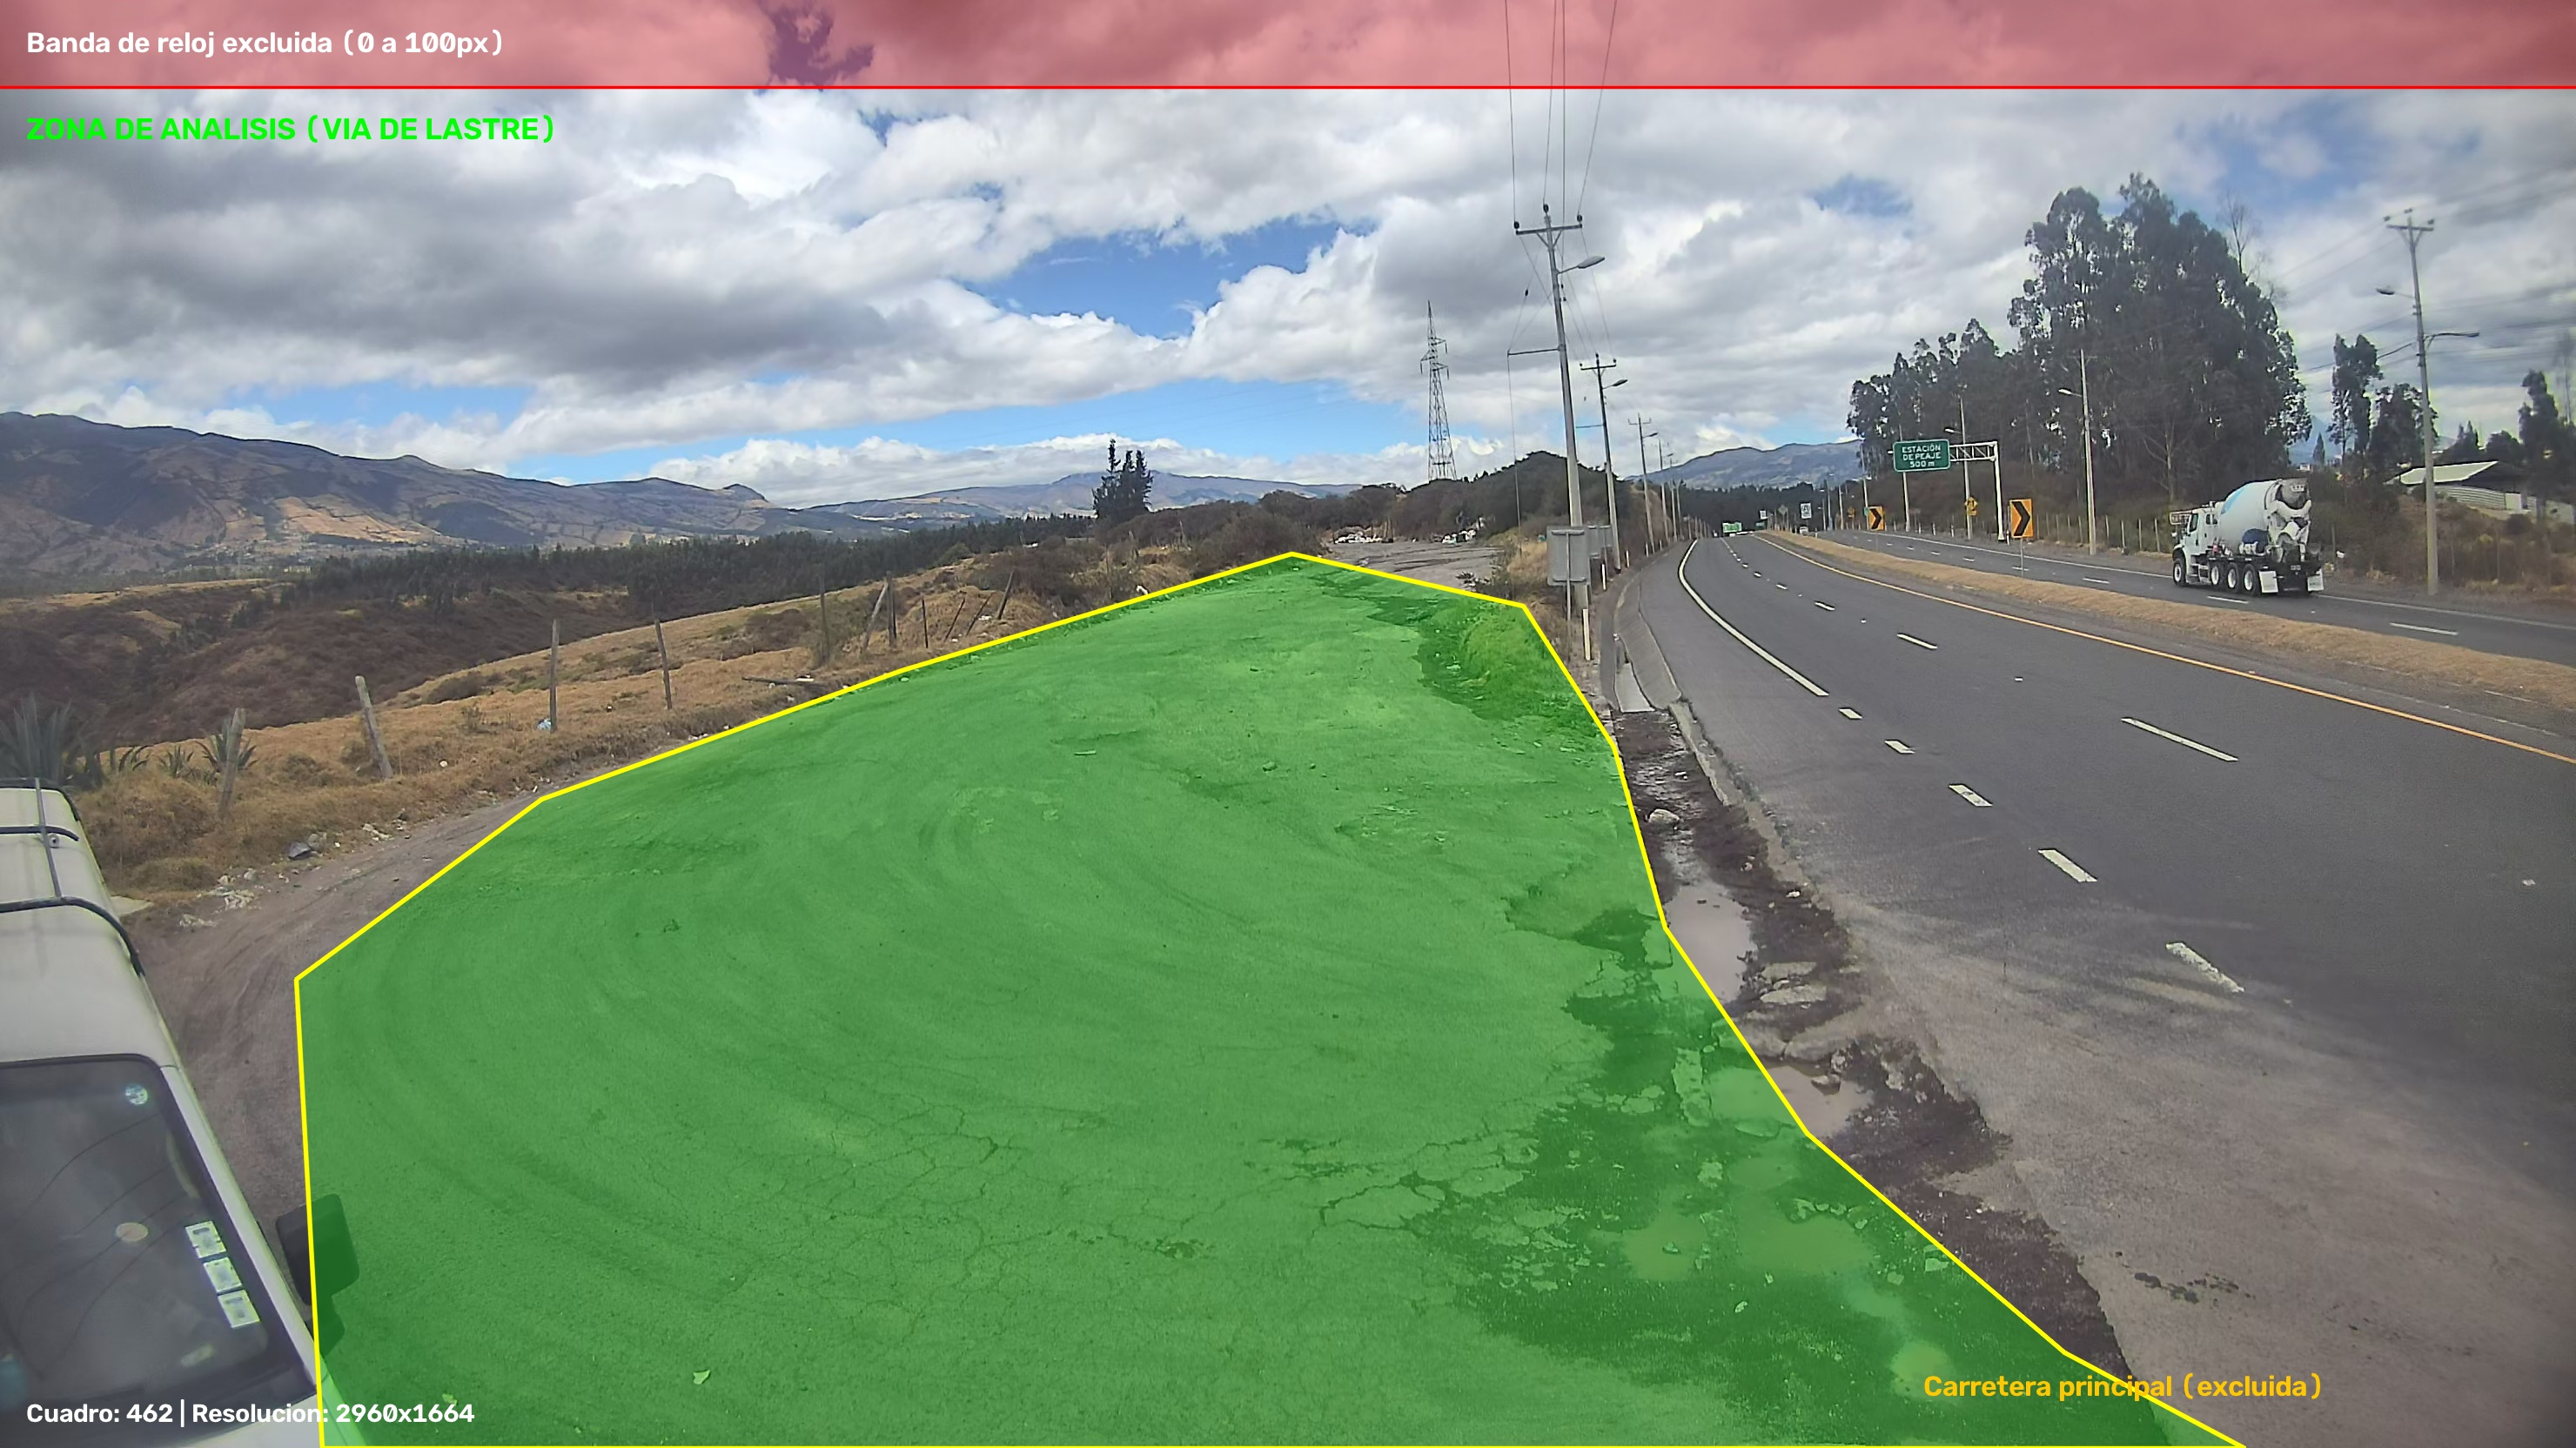

In [ ]:
from IPython.display import Image, display

# Sin --frame, el script elige un cuadro que exista en este video
!python scripts/verificar_zona.py "$PRIMER_VIDEO"

display(Image("out/verificacion_zona.jpg", width=950))

## 8. Prueba con 3 videos

Mide cuanto tarda antes de comprometer horas. La barra va de 0 a 100 sobre el
total de cuadros e incluye el tiempo restante estimado.

In [ ]:
!python scripts/procesar_lote.py "$CARPETA_VIDEOS" \
    --out-dir "$CARPETA_SALIDA" --acelerador $ACELERADOR --limite 3

PROCESAMIENTO DE LOTE
Carpeta:  /content/drive/MyDrive/Cam PL
Videos:   3
Computo:  GPU (CUDAExecutionProvider)
Midiendo duracion total del lote...
Cuadros totales: 17,337
Reanudando: 1 videos ya procesados
Avance: /content/drive/MyDrive/informe_lastre/avance.json
Reloj: plantillas de digitos cargadas
2026-09-11 19:14:43.239465672 [E:onnxruntime:Default, provider_bridge_ort.cc:2167 TryGetProviderInfo_TensorRT] /onnxruntime_src/onnxruntime/core/session/provider_bridge_ort.cc:1778 onnxruntime::Provider& onnxruntime::ProviderLibrary::Get() [ONNXRuntimeError] : 1 : FAIL : Failed to load library libonnxruntime_providers_tensorrt.so with error: libnvinfer.so.10: cannot open shared object file: No such file or directory

*************** EP Error ***************
EP Error /onnxruntime_src/onnxruntime/python/onnxruntime_pybind_state.cc:505 void onnxruntime::python::RegisterTensorRTPluginsAsCustomOps(PySessionOptions&, const onnxruntime::ProviderOptions&) Please install TensorRT libraries as ment

## 9. Revisar lo que produjo la prueba

In [ ]:
from openpyxl import load_workbook

libro = load_workbook(f"{CARPETA_SALIDA}/placas_lastre.xlsx")
hoja = libro["Placas"]
print(f"Vehiculos registrados: {hoja.max_row - 1}")
print()

for fila in hoja.iter_rows(min_row=1, max_row=min(11, hoja.max_row), values_only=True):
    print("  ".join(str(x)[:16].ljust(16) for x in fila[:7]))

print()
print("--- Resumen ---")
resumen = libro["Resumen"]
for i in range(3, 20):
    clave = resumen.cell(row=i, column=1).value
    if clave:
        print(f"  {clave}: {resumen.cell(row=i, column=2).value}")

Vehiculos registrados: 7

Registro          Placa             Hora de paso      Tiempo en video   Archivo de video  Tipo              Sentido         
V0001             PCX6575           2026-09-09 11:42  00:04             Camara Placas 2_  None              sale            
V0002             PCX6575           2026-09-09 11:42  00:28             Camara Placas 2_  None              sale            
V0003             ABM6665           2026-09-09 11:43  00:36             Camara Placas 2_  None              sale            
V0004             PBQ6756           2026-09-09 11:44  01:53             Camara Placas 2_  None              sale            
V0005             II110             2026-09-09 11:44  02:14             Camara Placas 2_  None              sale            
V0006             FBI776            2026-09-09 11:48  00:27             Camara Placas 2_  None              sale            
V0007             PDP6284           2026-09-09 11:49  01:34             Camara Placas 2_  None     

## 10. Procesar todos los videos

Agrega `--solo-salidas` si unicamente te interesan los que salen por el lastre.

**Si Colab se desconecta no pierdes nada.** El avance se guarda al terminar
cada video: vuelve a ejecutar esta misma celda y continua donde quedo.

In [ ]:
!python scripts/procesar_lote.py "$CARPETA_VIDEOS" \
    --out-dir "$CARPETA_SALIDA" --acelerador $ACELERADOR

PROCESAMIENTO DE LOTE
Carpeta:  /content/drive/MyDrive/Cam PL
Videos:   63
Computo:  GPU (CUDAExecutionProvider)
Midiendo duracion total del lote...
[mov,mp4,m4a,3gp,3g2,mj2 @ 0x2d21ca80] moov atom not found
  Aviso: no se pudo leer 'Camara Placas 2_20260909105651-20260909163038(48).mp4': No fue posible abrir el video con OpenCV: '/content/drive/MyDrive/Cam PL/Camara Placas 2_20260909105651-20260909163038(48).mp4'
[mov,mp4,m4a,3gp,3g2,mj2 @ 0x2d21ca80] moov atom not found
  Aviso: no se pudo leer 'Camara Placas 2_20260909105651-20260909163038(8).mp4': No fue posible abrir el video con OpenCV: '/content/drive/MyDrive/Cam PL/Camara Placas 2_20260909105651-20260909163038(8).mp4'
Cuadros totales: 479,997
Reanudando: 3 videos ya procesados
Avance: /content/drive/MyDrive/informe_lastre/avance.json
Reloj: plantillas de digitos cargadas
2026-09-11 19:28:57.179556956 [E:onnxruntime:Default, provider_bridge_ort.cc:2167 TryGetProviderInfo_TensorRT] /onnxruntime_src/onnxruntime/core/session/provid

## 11. Utilidades

Ejecuta solo la que necesites.

In [ ]:
# Ver cuantos videos van procesados
import json
with open(f"{CARPETA_SALIDA}/avance.json") as f:
    avance = json.load(f)
print(f"Videos procesados: {len(avance['videos'])}")
for nombre, datos in sorted(avance["videos"].items()):
    print(f"  {nombre}: {len(datos['filas'])} vehiculos")

In [ ]:
# Regenerar el Excel con lo ya procesado, sin analizar mas video
!python scripts/procesar_lote.py "$CARPETA_VIDEOS" --out-dir "$CARPETA_SALIDA" --solo-informe

In [ ]:
# Empezar de cero, descartando el avance guardado
!python scripts/procesar_lote.py "$CARPETA_VIDEOS" \
    --out-dir "$CARPETA_SALIDA" --acelerador $ACELERADOR --reiniciar

## Que obtienes

En la carpeta de salida de tu Drive:

- **`placas_lastre.xlsx`**, una fila por vehiculo con su foto al lado. Verde es
  validado, amarillo pendiente de revision, rojo sin placa legible. La segunda
  hoja resume los totales.
- **`recortes/`** con las imagenes sueltas.
- **`avance.json`** con el estado del procesamiento.

Revisa a mano las filas amarillas, y tambien las verdes con consenso bajo: esa
columna dice que tan disputada fue la lectura entre cuadros.